In [11]:
!pip install sentence-transformers scikit-learn pdfplumber python-docx matplotlib pandas numpy

In [12]:
# IMPORTS

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import precision_score, recall_score, f1_score

import pdfplumber
import docx
from google.colab import files

In [13]:
# MODEL

model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [14]:
uploaded_files = files.upload()

Saving AYISHA_JASMA.pdf to AYISHA_JASMA (1).pdf
Saving FATHIMA IBA.M.pdf to FATHIMA IBA.M (1).pdf
Saving SHANA_PARVEEN_KT.pdf to SHANA_PARVEEN_KT (1).pdf


In [20]:
# FILE READING

from io import BytesIO

def read_pdf(file):
    text = ""
    pdf_file = BytesIO(file)

    with pdfplumber.open(pdf_file) as pdf:
        for page in pdf.pages:
            text += page.extract_text() or ""

    return text

def read_docx(file):
    from io import BytesIO
    doc = docx.Document(BytesIO(file))
    return " ".join([para.text for para in doc.paragraphs])

def read_txt(file):
    return file.decode("utf-8")

def extract_text(file_name, file):
    if file_name.endswith(".pdf"):
        return read_pdf(file)
    elif file_name.endswith(".docx"):
        return read_docx(file)
    elif file_name.endswith(".txt"):
        return read_txt(file)
    return ""

In [21]:
# PREPROCESSING

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

In [22]:
# SECTION EXTRACTION

def extract_sections(text):
    sections = {"education": "", "experience": "", "certifications": ""}

    if "education" in text:
        sections["education"] = text.split("education")[1][:150]

    if "experience" in text:
        sections["experience"] = text.split("experience")[1][:150]

    if "certification" in text:
        sections["certifications"] = text.split("certification")[1][:150]

    return sections

In [23]:
# SKILL EXTRACTION

SKILL_MAP = {
    "python": ["python"],
    "machine learning": ["ml", "machine learning"],
    "deep learning": ["dl", "deep learning"],
    "nlp": ["nlp", "natural language processing"],
    "sql": ["sql"],
    "data analysis": ["data analysis", "analytics"],
    "pandas": ["pandas"],
    "numpy": ["numpy"],
    "tensorflow": ["tensorflow"],
    "pytorch": ["pytorch"],
}

def extract_skills(text):
    found = []
    for skill, variants in SKILL_MAP.items():
        for v in variants:
            if v in text:
                found.append(skill)
                break
    return list(set(found))

In [24]:
# LOAD RESUMES

resumes = []
resume_names = []

for file_name, file_data in uploaded_files.items():
    text = extract_text(file_name, file_data)
    clean = preprocess(text)

    if clean.strip():
        resumes.append(clean)
        resume_names.append(file_name)

In [25]:
# JOB DESCRIPTION

job_description = input("Enter Job Description:\n")
job_clean = preprocess(job_description)

Enter Job Description:
We are looking for a motivated Data Science Intern to join our team. The ideal candidate should have a strong foundation in data analysis and programming, with a keen interest in solving real-world problems using data-driven approaches.  Key Responsibilities: - Analyze structured and unstructured data to generate meaningful insights - Perform data cleaning, preprocessing, and exploratory data analysis (EDA) - Develop basic machine learning models for prediction and classification tasks - Work with large datasets using Python and relevant libraries - Create data visualizations and dashboards to communicate findings - Collaborate with team members on data-driven projects  Required Skills: - Proficiency in Python - Knowledge of SQL and data querying - Understanding of Machine Learning concepts - Experience with Pandas, NumPy, and Matplotlib - Basic knowledge of data visualization tools (Tableau / Power BI) - Strong analytical and problem-solving skills  Preferred Qu

In [26]:
# EMBEDDINGS

resume_embeddings = model.encode(resumes)
jd_embedding = model.encode([job_clean])[0]

In [27]:
# RESULTS

results = []

for i, emb in enumerate(resume_embeddings):
    score = cosine_similarity([emb], [jd_embedding])[0][0]
    skills = extract_skills(resumes[i])
    sections = extract_sections(resumes[i])

    results.append({
        "Name": resume_names[i],
        "Score": round(score, 4),
        "Skills": skills,
        "Education": sections["education"],
        "Experience": sections["experience"],
        "Text": resumes[i]
    })

results = sorted(results, key=lambda x: x["Score"], reverse=True)

In [28]:
# EXPLANATION

def explain(resume, jd):
    return list(set(resume.split()) & set(jd.split()))[:10]

for r in results:
    r["Explanation"] = explain(r["Text"], job_clean)

In [29]:
# DATAFRAME

df = pd.DataFrame(results)
df

,Name,Score,Skills,Education,Experience,Text,Explanation
0,FATHIMA IBA.M (1).pdf,0.7147,"[python, machine learning, data analysis, pand...",pg diploma in data science westberg internati...,d in building pre dictive models performing ex...,fathima ibam email fathimaibamgmailcom phone 6...,"[data, solving, and, pandas, generate, sql, of..."
1,SHANA_PARVEEN_KT (1).pdf,0.6763,"[python, machine learning, data analysis, sql,...",pg diploma in data science 2025 present westb...,developing datadriven analytical applications...,shana parveen kt data science machine learning...,"[data, and, pandas, generate, sql, of, problem..."
2,AYISHA_JASMA (1).pdf,0.5790,"[python, machine learning, data analysis, pand...",pg diploma in data science present westberg i...,indataanalysisandmachinelearning skilledinwork...,1aysha jasma india jasmajasimjasmagmailcom 91 ...,"[data, and, pandas, generate, sql, of, problem..."


In [30]:
# THRESHOLD

THRESHOLD = 0.5

shortlisted = df[df["Score"] >= THRESHOLD]
print("Shortlisted Candidates:")
shortlisted

Shortlisted Candidates:


,Name,Score,Skills,Education,Experience,Text,Explanation
0,FATHIMA IBA.M (1).pdf,0.7147,"[python, machine learning, data analysis, pand...",pg diploma in data science westberg internati...,d in building pre dictive models performing ex...,fathima ibam email fathimaibamgmailcom phone 6...,"[data, solving, and, pandas, generate, sql, of..."
1,SHANA_PARVEEN_KT (1).pdf,0.6763,"[python, machine learning, data analysis, sql,...",pg diploma in data science 2025 present westb...,developing datadriven analytical applications...,shana parveen kt data science machine learning...,"[data, and, pandas, generate, sql, of, problem..."
2,AYISHA_JASMA (1).pdf,0.5790,"[python, machine learning, data analysis, pand...",pg diploma in data science present westberg i...,indataanalysisandmachinelearning skilledinwork...,1aysha jasma india jasmajasimjasmagmailcom 91 ...,"[data, and, pandas, generate, sql, of, problem..."


In [31]:
# Example: 1 = relevant, 0 = not
y_true = [1, 0, 1, 1][:len(results)]

In [32]:
y_pred = [1 if r["Score"] >= THRESHOLD else 0 for r in results]

In [33]:
# EVALUATION METRICS

print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))

Precision: 0.6666666666666666
Recall: 1.0
F1 Score: 0.8


In [34]:
# MRR

def compute_mrr(results, y_true):
    for i, (r, true) in enumerate(zip(results, y_true)):
        if true == 1:
            return 1 / (i + 1)
    return 0

print("MRR:", compute_mrr(results, y_true))

MRR: 1.0


In [35]:
# NDCG

def dcg(scores):
    return sum([rel / np.log2(i + 2) for i, rel in enumerate(scores)])

def ndcg(y_true):
    ideal = sorted(y_true, reverse=True)
    return dcg(y_true) / dcg(ideal)

print("NDCG:", ndcg(y_true))

NDCG: 0.9197207891481876


In [36]:
# PROCESSING TIME

start = time.time()
_ = model.encode(resumes)
end = time.time()

print("Processing Time:", end - start, "seconds")

Processing Time: 0.3265986442565918 seconds


In [37]:
# ROBUSTNESS TEST

noisy_resume = "pythn ml dl data scince experiance"
clean_noisy = preprocess(noisy_resume)

emb = model.encode([clean_noisy])[0]
score = cosine_similarity([emb], [jd_embedding])[0][0]

print("Noisy Resume Score:", score)

Noisy Resume Score: 0.29464543


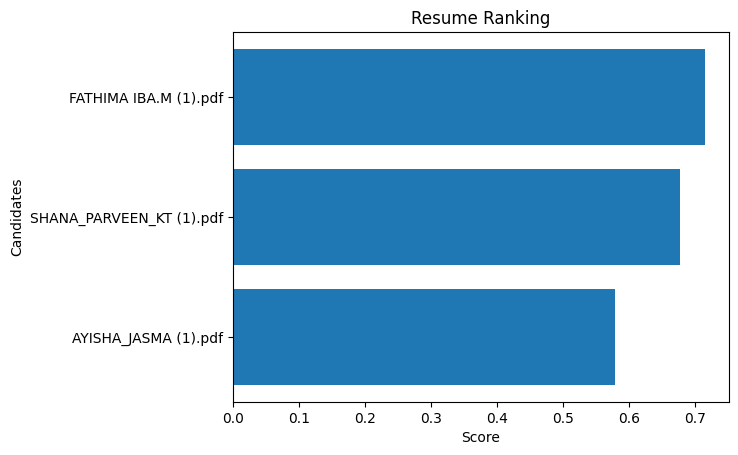

In [38]:
# VISUALIZATION

plt.figure()
plt.barh(df["Name"], df["Score"])
plt.xlabel("Score")
plt.ylabel("Candidates")
plt.title("Resume Ranking")
plt.gca().invert_yaxis()
plt.show()